In [ ]:
# Importing all the required libraries that will be used throughout this project.
# Pandas is used for handling and analysing data, NumPy is used for numerical operations
# Matplotlib and Seaborn are used for data visualisation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# From sklearn, we import tools needed for splitting data, building the model,and evaluating its performance.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Loading the dataset from a CSV file into a pandas DataFrame.

df = pd.read_csv("bank-full.csv")

# Displaying the first few rows of the dataset to get a quick understanding
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Checking the basic structure of the dataset such as data types, number of non-null values, and overall size of the dataset.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


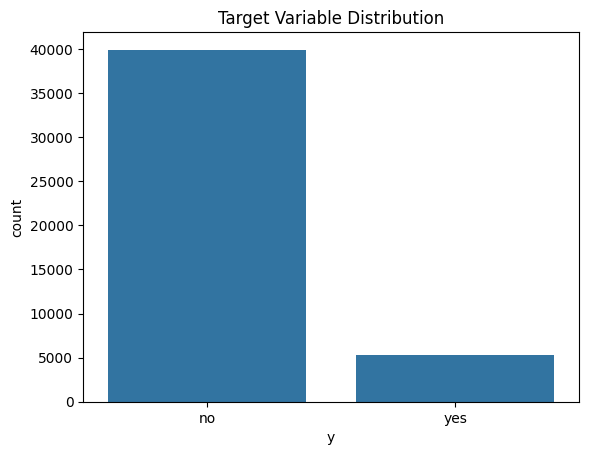

In [ ]:
# Visualising the distribution of the target variable 'y'.
# This helps us understand whether the dataset is balanced or imbalanced,
# meaning whether there are similar numbers of 'yes' and 'no' outcomes.
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [ ]:
# Converting the target variable from categorical values ('yes' and 'no')
# into numerical format (1 and 0). This is required because machine learning models work with numerical data, not text
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:
# Converting all categorical features into numerical form using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
# Separating the dataset into input features (X) and the target variable (y)

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [ ]:
# Splitting the dataset into training and testing sets.
# The model is trained on 80% of the data and tested on the remaining 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (36168, 42)
Testing size: (9043, 42)


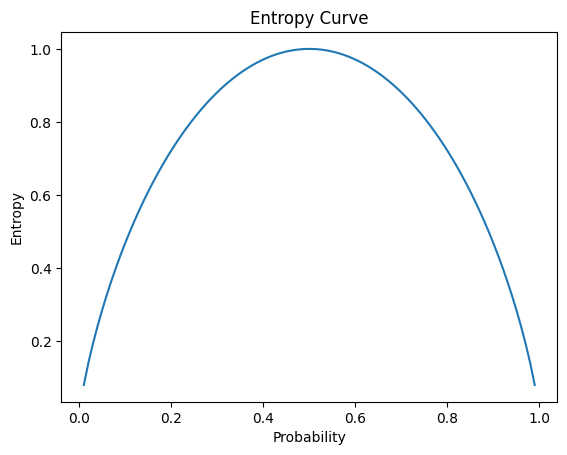

In [ ]:
# Defining a function to calculate entropy, which is a measure of impurity.

def entropy(p):
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

p = np.linspace(0.01, 0.99, 100)
ent = entropy(p)

plt.plot(p, ent)
plt.title("Entropy Curve")
plt.xlabel("Probability")
plt.ylabel("Entropy")
plt.show()

In [ ]:
# Training the model with the dataset

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# Making Prediction with test data on behalf of trained data

y_pred = model.predict(X_test)

In [ ]:
# Here we evaluate how well the trained model performs on unseen data.
# Accuracy measures the overall percentage of correct predictions.

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# The classification report provides deeper insights into model performance.
# It includes precision (how many predicted positives are correct),
# recall (how many actual positives are correctly predicted),
# and F1-score (balance between precision and recall).

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8973791883224593

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



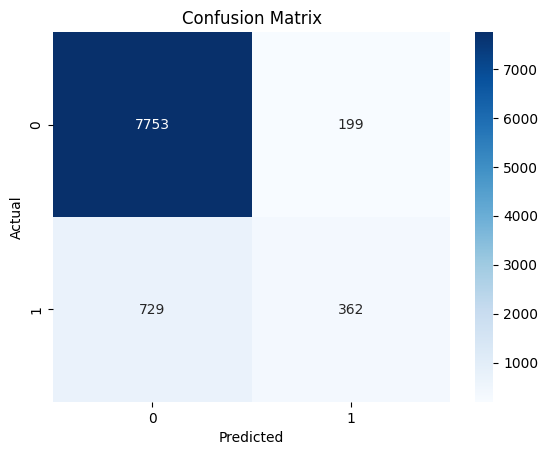

In [ ]:
# A confusion matrix is created to compare actual vs predicted values.

cm = confusion_matrix(y_test, y_pred)

# Visualising the confusion matrix using a heatmap makes it easier to interpret.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

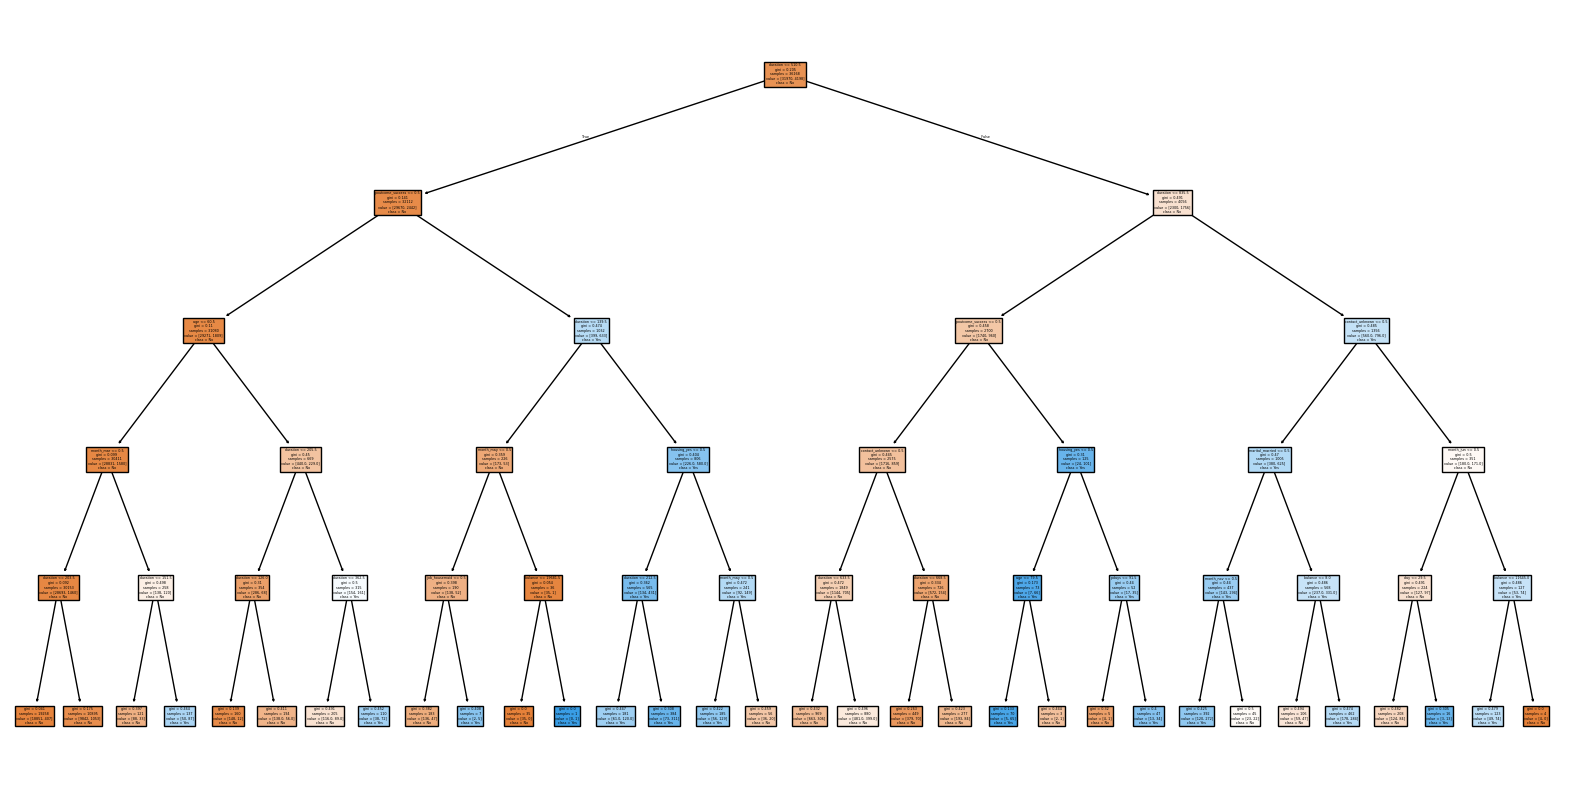

In [ ]:
# Plotting the decision tree helps us understand how the model makes decisions.
# Each node represents a condition, and branches represent outcomes.

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.show()

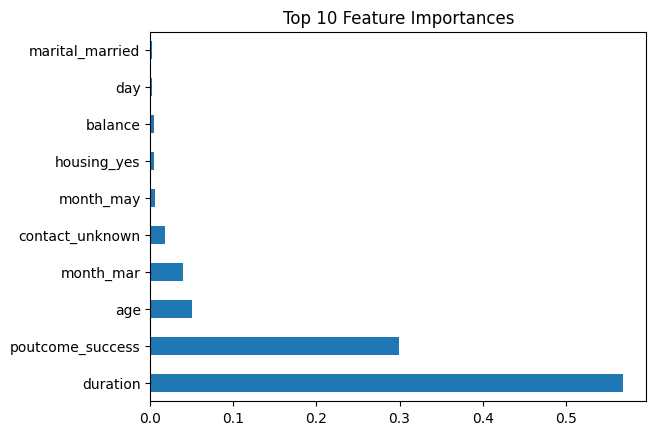

In [ ]:
# Extracting feature importance values from the trained model.

importances = model.feature_importances_

# Converting feature importance into a pandas Series for easier sorting and display.
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)[:10]

# Plotting the top features to visually understand which variables influence the model most.
feat_imp.plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

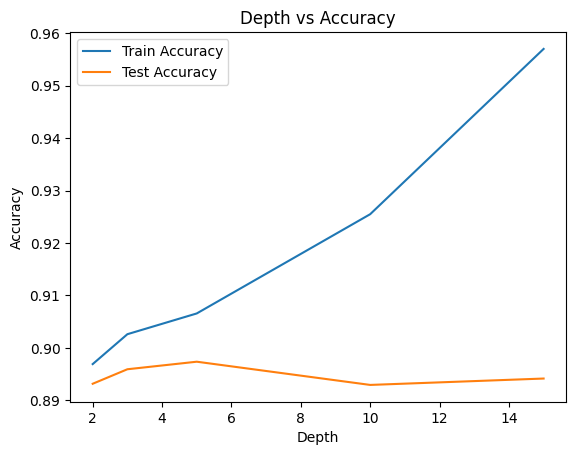

In [ ]:
# Testing different tree depths to see how model performance changes.

depths = [2, 3, 5, 10, 15]
train_acc = []
test_acc = []

# Looping through different depth values and training separate models.
for d in depths:
    temp_model = DecisionTreeClassifier(max_depth=d, random_state=42)
    temp_model.fit(X_train, y_train)

    train_acc.append(temp_model.score(X_train, y_train))
    test_acc.append(temp_model.score(X_test, y_test))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Depth vs Accuracy")
plt.show()

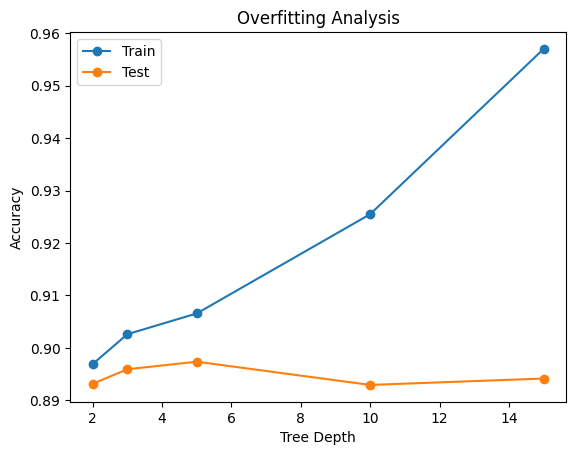

In [ ]:
# Overfitting view
# This graph focuses specifically on visualising overfitting.
# If training accuracy is very high but testing accuracy drops,
# it indicates that the model is memorising data instead of learning patterns.

plt.plot(depths, train_acc, marker='o')
plt.plot(depths, test_acc, marker='o')

plt.title("Overfitting Analysis")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])
plt.show()

In [ ]:
# Selecting a single sample from the test dataset.

sample = X_test.iloc[0].values.reshape(1, -1)

# Using the trained model to predict the output for this sample
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
